# World Cup Predictor Model 2026
By Karl Estampador :)

## Model description

This notebook loads the 2026 Elo ratings and exposes three functions used by `predictions.ipynb`:

| Function | Returns |
|---|---|
| `get_elo(team_name)` | Elo rating for a team |
| `predict_winner(home, away)` | `(winner, loser, winner_elo, loser_elo)` — higher Elo always wins |
| `predict_score(home, away)` | `(home_goals, away_goals)` — winner scores 2; loser 0 (or 1-0 if Elo diff < 50) |

In [1]:
import pandas as pd
from pathlib import Path

DATA = Path('data')

## 1. Load Elo ratings (based on Elo ratings from May 27, 2026)

In [2]:
elo_raw = pd.read_csv(DATA / 'elo_ratings_wc2026.csv')
elo_2026 = (
    elo_raw[elo_raw['snapshot_date'] == '2026-05-27']
    .copy()
    .reset_index(drop=True)
)
print(f'{len(elo_2026)} teams in 2026-05-27 Elo snapshot')
elo_2026[['country', 'rating', 'rank']].sort_values('rank').head(10)

48 teams in 2026-05-27 Elo snapshot


,country,rating,rank
0,Spain,2165,1
1,Argentina,2113,2
2,France,2081,3
3,England,2020,4
4,Brazil,1984,5
5,Portugal,1984,5
6,Colombia,1975,7
7,Netherlands,1961,8
8,Ecuador,1933,9
9,Croatia,1930,10


## 2. Load teams and FIFA rank tiebreaker

In [3]:
teams_df = pd.read_csv(DATA / 'teams.csv')
test_df  = pd.read_csv(DATA / 'test.csv')

# fifa_rank_pre_tournament is in test.csv, keyed by team name
fifa_rank = dict(zip(test_df['team'], test_df['fifa_rank_pre_tournament']))
print(f'{len(teams_df)} teams loaded; {len(fifa_rank)} FIFA ranks available')
teams_df.head()

48 teams loaded; 48 FIFA ranks available


,id,team_name,fifa_code,group_letter,is_placeholder
0,1,Mexico,MEX,A,False
1,2,South Africa,RSA,A,False
2,3,South Korea,KOR,A,False
3,4,Czechia,CZE,A,False
4,5,Canada,CAN,B,False


## 3. Team name alias map

Three naming schemes exist across files. This map normalises any source name to the key used in `elo_2026['country']`.

In [4]:
# maps any variant name to the country name in the elo database
ALIASES: dict[str, str] = {
    # teams.csv / matches.csv -> elo country
    'USA':                      'United States',
    'IR Iran':                  'Iran',
    "Côte d'Ivoire":            'Ivory Coast',
    'Cabo Verde':               'Cape Verde',
    'DR Congo':                 'DR Congo',       
    # test.csv / train.csv variants
    'United States':            'United States',
    'Iran':                     'Iran',
    'Ivory Coast':              'Ivory Coast',
    'Cape Verde':               'Cape Verde',
    'Czech Republic':           'Czechia',
    'Cura\u00e7ao':             'Cura\u00e7ao', # special c character
}

# Build Elo lookup: canonical name -> rating
_elo_lookup: dict[str, float] = dict(zip(elo_2026['country'], elo_2026['rating']))

# Build FIFA rank lookup accepting any variant name
_rank_lookup: dict[str, float] = {}
for name, rank in fifa_rank.items():
    _rank_lookup[name] = rank
    canon = ALIASES.get(name, name)
    _rank_lookup[canon] = rank

# resolve any team name variant to the canonical Elo country name
def _canonical(name: str) -> str:
    return ALIASES.get(name, name)

# returns pre-tournament Elo rating for team name
def get_elo(team_name: str) -> float:
    canon = _canonical(team_name)
    if canon in _elo_lookup:
        return _elo_lookup[canon]
    # Fallback: try the original name
    if team_name in _elo_lookup:
        return _elo_lookup[team_name]
    raise KeyError(f'No Elo rating found for "{team_name}" (canonical: "{canon}")')

# gets FIFA rank for a tiebreaker if elo is the same
def _get_fifa_rank(team_name: str) -> float:
    canon = _canonical(team_name)
    for key in (team_name, canon):
        if key in _rank_lookup:
            v = _rank_lookup[key]
            try:
                return float(v)
            except (TypeError, ValueError):
                pass
    return 999.0 # if we can't find FIFA rank


print('Alias map and Elo lookup ready.')
# Quick sanity check to make sure elo lookup is working
for t in ['Spain', 'USA', 'IR Iran', "Côte d'Ivoire", 'Bosnia and Herzegovina', 'Iraq', 'DR Congo', 'Czechia', 'Sweden', 'Turkey']:
    print(f'  {t:35s} Elo={get_elo(t):.0f}')

Alias map and Elo lookup ready.
  Spain                               Elo=2165
  USA                                 Elo=1721
  IR Iran                             Elo=1760
  Côte d'Ivoire                       Elo=1676
  Bosnia and Herzegovina              Elo=1594
  Iraq                                Elo=1607
  DR Congo                            Elo=1655
  Czechia                             Elo=1726
  Sweden                              Elo=1719
  Turkey                              Elo=1902


## 4. Core model functions

In [5]:
# predicts the winner of a match between home and away, higher elo always wins,
# then lower FIFA rank wins. 
def predict_winner(
    home: str, away: str
) -> tuple[str, str, float, float]:

    home_elo = get_elo(home)
    away_elo = get_elo(away)

    if home_elo > away_elo:
        return home, away, home_elo, away_elo
    elif away_elo > home_elo:
        return away, home, away_elo, home_elo
    else:
        # Extremely rare exact tie: use FIFA rank
        home_rank = _get_fifa_rank(home)
        away_rank = _get_fifa_rank(away)
        if home_rank <= away_rank:
            return home, away, home_elo, away_elo
        else:
            return away, home, away_elo, home_elo

# produce a scoreline for group-stage use
def predict_score(home: str, away: str) -> tuple[int, int]:
    winner, loser, w_elo, l_elo = predict_winner(home, away)
    diff = abs(w_elo - l_elo)
    goals_w = 2 if diff >= 50 else 1
    goals_l = 0
    if winner == home:
        return goals_w, goals_l
    else:
        return goals_l, goals_w


# Compatibility stubs so predictions.ipynb works with either model notebook
def predict_group_match(home: str, away: str) -> tuple[int, int, str | None]:
    """ELO model never predicts draws; always returns a winner."""
    hg, ag = predict_score(home, away)
    w, _, _, _ = predict_winner(home, away)
    return hg, ag, w

def predict_knockout_winner(home: str, away: str) -> tuple[str, str, float, float]:
    """Thin alias for predict_winner for the ELO model."""
    return predict_winner(home, away)

print('predict_winner and predict_score ready.')

# Demo
demo_matches = [
    ('Mexico',     'South Africa'),
    ('South Korea', 'Czechia'),
    ('Canada', 'Bosnia and Herzegovina'),
    ('United States',    'Paraguay'),
]
print(f'\n{"Match":<35} {"Winner":<30} {"Score"}')
print('-' * 75)
for h, a in demo_matches:
    w, l, we, le = predict_winner(h, a)
    hg, ag = predict_score(h, a)
    print(f'{h} vs {a:<25} {w:<30} {hg}-{ag}  (Elo: {we:.0f} vs {le:.0f})')

predict_winner and predict_score ready.

Match                               Winner                         Score
---------------------------------------------------------------------------
Mexico vs South Africa              Mexico                         2-0  (Elo: 1860 vs 1524)
South Korea vs Czechia                   South Korea                    1-0  (Elo: 1752 vs 1726)
Canada vs Bosnia and Herzegovina    Canada                         2-0  (Elo: 1784 vs 1594)
United States vs Paraguay                  Paraguay                       0-2  (Elo: 1833 vs 1721)


---
## 5. Historical accuracy evaluation

How well does the ELO model actually predict results? We backtest on the same 2006–2022 World Cup matches used to evaluate `lr_model.ipynb`, so the two models can be compared directly.

**Method:**
- Same outcome labels as LR (`home_win` / `away_win` / `draw`, with penalty shootout resolution for knockout draws)
- **Era-appropriate ELO**: each match uses the latest ELO snapshot *on or before the match date* — no future leakage. A June 2006 match uses the `2005-12-31` ratings, not 2026 ratings.
- **Coverage**: only the ~192 of 320 matches where both teams appear in the ELO file are scored. The other ~128 involve nations (Italy, Poland, Serbia, Russia, etc.) that are not tracked in `elo_ratings_wc2026.csv`.
- **5-fold stratified CV** (same `random_state=42` as LR) — since ELO is deterministic, this measures fold-to-fold variance rather than training variance, giving a comparable ± figure.

In [6]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ── Load data needed for evaluation ──────────────────────────────────────────
results_eval = pd.read_csv(DATA / 'historical_results' / 'results.csv')
shootouts_eval = pd.read_csv(DATA / 'historical_results' / 'shootouts.csv')
train_eval = pd.read_csv(DATA / 'train.csv')

results_eval['year'] = pd.to_datetime(results_eval['date']).dt.year
shootouts_eval['year'] = pd.to_datetime(shootouts_eval['date']).dt.year

wc_eval = results_eval[
    (results_eval['tournament'] == 'FIFA World Cup') &
    results_eval['year'].between(2006, 2022)
].copy().reset_index(drop=True)

wc_shootouts_eval = shootouts_eval[shootouts_eval['year'].between(2006, 2022)].copy()

# ── Name normalisation (mirrors lr_model.ipynb) ───────────────────────────────
# Maps results.csv names to the canonical form used in elo_ratings_wc2026.csv
EVAL_ALIASES: dict[str, str] = {
    'USA':            'United States',
    'Czech Republic': 'Czechia',
    'Ivory Coast':    'Ivory Coast',
    'IR Iran':        'Iran',
}

def _eval_canon(name: str) -> str:
    return EVAL_ALIASES.get(name, name)

def _norm_to_elo(name: str, year: int) -> str:
    """Map results.csv team name to its ELO-file equivalent."""
    if name == 'Serbia' and year == 2006:
        return 'Serbia and Montenegro'
    if name == 'China':
        return 'China PR'
    return name

wc_eval['home_norm'] = wc_eval.apply(lambda r: _norm_to_elo(r['home_team'], r['year']), axis=1)
wc_eval['away_norm'] = wc_eval.apply(lambda r: _norm_to_elo(r['away_team'], r['year']), axis=1)

# ── Outcome labels (shootout resolution for knockout draws) ───────────────────
_shootout_lkp: dict[tuple, str] = {}
for _, row in wc_shootouts_eval.iterrows():
    _shootout_lkp[(row['date'], row['home_team'], row['away_team'])] = row['winner']

def _outcome_label(row: pd.Series) -> str:
    if row['home_score'] > row['away_score']:
        return 'home_win'
    if row['away_score'] > row['home_score']:
        return 'away_win'
    w = _shootout_lkp.get((row['date'], row['home_team'], row['away_team']))
    if w is not None:
        return 'home_win' if w == row['home_team'] else 'away_win'
    return 'draw'

wc_eval['outcome'] = wc_eval.apply(_outcome_label, axis=1)

# ── Era-appropriate ELO helpers ───────────────────────────────────────────────
# elo_raw was loaded in cell 3; convert snapshot_date to datetime once
elo_hist = elo_raw.copy()
elo_hist['snapshot_date'] = pd.to_datetime(elo_hist['snapshot_date'])
# Sort once so that filtering by country + date gives us iloc[-1] = latest valid snapshot
elo_hist_sorted = elo_hist.sort_values(['country', 'snapshot_date']).reset_index(drop=True)
_elo_all_countries: set[str] = set(elo_hist['country'].unique())

def _get_elo_at(team: str, match_date: pd.Timestamp) -> float | None:
    """Era-appropriate ELO: latest snapshot on or before match_date (no future leakage)."""
    for name in (_eval_canon(team), team):
        mask = (elo_hist_sorted['country'] == name) & (elo_hist_sorted['snapshot_date'] <= match_date)
        rows = elo_hist_sorted[mask]
        if not rows.empty:
            return float(rows.iloc[-1]['rating'])
    return None

# Historical FIFA rank for exact-ELO-tie tiebreaking (from train.csv, same as LR)
_hist_ranks: dict[tuple, float] = {}
for _, row in train_eval.iterrows():
    _hist_ranks[(int(row['version']), row['team'])] = row['fifa_rank_pre_tournament']

def _get_hist_rank(team: str, year: int) -> float:
    for name in (team, _norm_to_elo(team, year), _eval_canon(team)):
        v = _hist_ranks.get((year, name))
        if v is not None:
            try:
                return float(v)
            except (TypeError, ValueError):
                pass
    return 999.0

# ── Filter to ELO-evaluable matches ──────────────────────────────────────────
def _has_hist_elo(team: str) -> bool:
    c = _eval_canon(team)
    return c in _elo_all_countries or team in _elo_all_countries

wc_eval['elo_ok'] = wc_eval.apply(
    lambda r: _has_hist_elo(r['home_norm']) and _has_hist_elo(r['away_norm']), axis=1
)
eval_df = wc_eval[wc_eval['elo_ok']].copy().reset_index(drop=True)
eval_df['match_date'] = pd.to_datetime(eval_df['date'])

n_total = len(wc_eval)
n_eval = len(eval_df)
print(f'WC matches 2006–2022 : {n_total}')
print(f'ELO-evaluable        : {n_eval}  (both teams in ELO file)')
print(f'Skipped              : {n_total - n_eval}  (team not in ELO file)')
print()
print('Outcome distribution on evaluable subset:')
print(eval_df['outcome'].value_counts().to_string())

# ── Sanity check: confirm era-appropriate snapshot selection ──────────────────
print()
print('Snapshot date used per sample match (verify era-matching):')
print(f'{"Date":<12}  {"Home":<22}  {"Away":<22}  {"Home ELO date":<14}  Away ELO date')
print('-' * 92)
for _, row in eval_df.sample(5, random_state=1).iterrows():
    md = row['match_date']
    def snap_date(team):
        for nm in (_eval_canon(team), team):
            rows = elo_hist_sorted[
                (elo_hist_sorted['country'] == nm) & (elo_hist_sorted['snapshot_date'] <= md)
            ]
            if not rows.empty:
                return str(rows.iloc[-1]['snapshot_date'].date())
        return 'N/A'
    hs = snap_date(row['home_norm'])
    as_ = snap_date(row['away_norm'])
    print(f'{row["date"]:<12}  {row["home_norm"]:<22}  {row["away_norm"]:<22}  {hs:<14}  {as_}')

WC matches 2006–2022 : 320
ELO-evaluable        : 192  (both teams in ELO file)
Skipped              : 128  (team not in ELO file)

Outcome distribution on evaluable subset:
outcome
home_win    95
away_win    67
draw        30

Snapshot date used per sample match (verify era-matching):
Date          Home                    Away                    Home ELO date   Away ELO date
--------------------------------------------------------------------------------------------
2010-06-17    France                  Mexico                  2009-12-31      2009-12-31
2014-06-12    Brazil                  Croatia                 2013-12-31      2013-12-31
2022-11-27    Spain                   Germany                 2021-12-31      2021-12-31
2006-07-08    Germany                 Portugal                2005-12-31      2005-12-31
2022-12-06    Morocco                 Spain                   2021-12-31      2021-12-31


Historical ELO backtest (2006–2022 World Cup)
  Matches scored     : 192 / 320  (LR training set)
  3-class accuracy   : 0.583  ±0.050
  Random baseline    : 0.333

For comparison — LR model (full 320 matches): 0.578 ±0.044
Note: ELO never predicts draws; LR can predict all 3 outcomes.

Per-fold accuracy:
  Fold 1  0.590  ████████████████████████
  Fold 2  0.590  ████████████████████████
  Fold 3  0.579  ███████████████████████
  Fold 4  0.500  ████████████████████
  Fold 5  0.658  ██████████████████████████


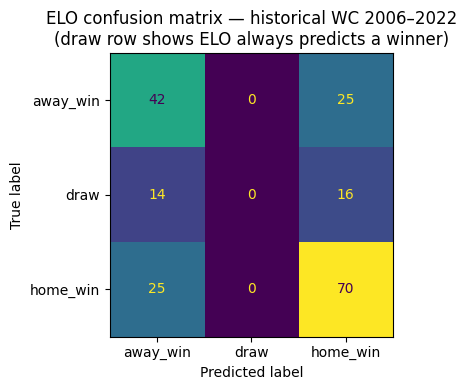

In [7]:
# ── Pre-compute ELO predictions for every evaluable match ────────────────────
def _elo_pred(row: pd.Series) -> str:
    md = row['match_date']
    yr = int(row['year'])
    home, away = row['home_norm'], row['away_norm']

    h_elo = _get_elo_at(home, md)
    a_elo = _get_elo_at(away, md)

    if h_elo is None or a_elo is None:
        return 'unknown'  # shouldn't occur after elo_ok filter

    if h_elo > a_elo:
        return 'home_win'
    elif a_elo > h_elo:
        return 'away_win'
    else:
        # Exact tie: lower FIFA rank wins (same logic as predict_winner)
        h_rank = _get_hist_rank(home, yr)
        a_rank = _get_hist_rank(away, yr)
        return 'home_win' if h_rank <= a_rank else 'away_win'

y_true = eval_df['outcome'].values
y_pred = eval_df.apply(_elo_pred, axis=1).values

# ── 5-fold stratified CV (same settings as lr_model.ipynb) ───────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accs = []
for fold_i, (_, test_idx) in enumerate(cv.split(eval_df, y_true), start=1):
    fold_acc = (y_pred[test_idx] == y_true[test_idx]).mean()
    fold_accs.append(fold_acc)

mean_acc = float(np.mean(fold_accs))
std_acc  = float(np.std(fold_accs))

print('Historical ELO backtest (2006–2022 World Cup)')
print('=' * 46)
print(f'  Matches scored     : {n_eval} / {n_total}  (LR training set)')
print(f'  3-class accuracy   : {mean_acc:.3f}  \u00b1{std_acc:.3f}')
print(f'  Random baseline    : 0.333')
print()
print(f'For comparison \u2014 LR model (full {n_total} matches): 0.578 \u00b10.044')
print('Note: ELO never predicts draws; LR can predict all 3 outcomes.')

# ── Per-fold breakdown ────────────────────────────────────────────────────────
print()
print('Per-fold accuracy:')
for i, acc in enumerate(fold_accs, start=1):
    bar = '\u2588' * round(acc * 40)
    print(f'  Fold {i}  {acc:.3f}  {bar}')

# ── Confusion matrix ──────────────────────────────────────────────────────────
CLASS_LABELS_EVAL = ['away_win', 'draw', 'home_win']

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    labels=CLASS_LABELS_EVAL,
    display_labels=CLASS_LABELS_EVAL,
    ax=ax,
    colorbar=False,
)
ax.set_title('ELO confusion matrix — historical WC 2006–2022\n(draw row shows ELO always predicts a winner)')
plt.tight_layout()
plt.show()